# dmpbridge — Comparison Dashboard

Central view across all models and all experiment variants.  
For per-model deep dives see the individual `03_eval_<model>.ipynb` notebooks.

| Section | Content |
|---|---|
| 1 | Executive summary — all key numbers at a glance |
| 2 | Model comparison — per-sample accuracy and per-label F1 |
| 3 | Cross-model error analysis — how many models got each block right |
| 4 | Error drill-down — interactive block filter |

## Setup

In [1]:
import sys
sys.path.insert(0, "..")

from evaluate import extract_gold, evaluate_sample, match, LABELS, SHORT, LLM_DIR, MANUAL_DIR, NO_MATCH
import json
from collections import defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"white",
    "axes.edgecolor":"#555555", "axes.linewidth":0.8,
    "grid.color":"#dddddd",     "grid.linewidth":0.5,
    "text.color":"#111111",     "axes.labelcolor":"#111111",
    "xtick.color":"#111111",    "ytick.color":"#111111",
    "font.size":11, "axes.titlesize":13, "axes.labelsize":11,
    "xtick.labelsize":10, "ytick.labelsize":10,
    "legend.fontsize":10, "legend.frameon":True, "legend.edgecolor":"#cccccc",
    "figure.dpi":120,
})

# ── Model registry — add new models here ──────────────────────────────────────
TAGS = {
    "llama3.3:70b":    "llama3.3-70b",
    "llama3.1:8b":     "llama3.1-8b",
    "claude-opus-4-8": "claude-opus-4-8",
}

MODEL_COLORS = {
    "llama3.3:70b":    "#2563eb",
    "llama3.1:8b":     "#dc2626",
    "claude-opus-4-8": "#7c3aed",
}

def _snum(p):
    s = p.stem if hasattr(p, "stem") else p
    return int(s.replace("_dmp","").replace("sample",""))

samples = sorted(MANUAL_DIR.glob("*_dmp.json"), key=_snum)

def _f1(conf, lbl):
    tp = conf.get(lbl,{}).get(lbl,0)
    fp = sum(conf.get(o,{}).get(lbl,0) for o in LABELS if o!=lbl)
    fn = sum(v for p,v in conf.get(lbl,{}).items() if p!=lbl)
    p_ = tp/(tp+fp) if (tp+fp) else 0.
    r_ = tp/(tp+fn) if (tp+fn) else 0.
    return 2*p_*r_/(p_+r_) if (p_+r_) else 0.

def load_variant(tag):
    rows, conf = [], defaultdict(lambda: defaultdict(int))
    for mp in samples:
        stem = mp.stem.replace("_dmp","")
        pp   = LLM_DIR / f"{stem}_{tag}.json"
        if not pp.exists():
            continue
        gold = extract_gold(mp)
        c    = evaluate_sample(pp, gold)
        for tl,preds in c.items():
            for pl,cnt in preds.items():
                conf[tl][pl] += cnt
        tp = sum(c.get(l,{}).get(l,0) for l in LABELS)
        n  = sum(sum(v.values()) for v in c.values())
        rows.append({"sample":stem,"total":n,"correct":tp,
                     "errors":n-tp,"accuracy":tp/n if n else 0})
    return pd.DataFrame(rows), conf

variants = {k: load_variant(v) for k,v in TAGS.items()}
print("Loaded variants:")
for model,(df,_) in variants.items():
    if df.empty: print(f"  MISSING  {model}"); continue
    tc,tn = int(df["correct"].sum()), int(df["total"].sum())
    print(f"  {model:<20}  {tc}/{tn}  ({tc/tn*100:.1f}%)")

Loaded variants:
  llama3.3:70b          697/741  (94.1%)
  llama3.1:8b           499/741  (67.3%)
  claude-opus-4-8       703/741  (94.9%)


## 1 — Executive Summary

In [2]:
print("=" * 80)
print("  dmpbridge — Comparison Dashboard")
print("=" * 80)
hdr = f"{'Model':<22}  {'Accuracy':>8}  {'q.text F1':>10}  {'sec.desc F1':>12}  {'ans.text F1':>12}"
print("\n" + hdr)
print("-" * len(hdr))
for model,(df,conf) in variants.items():
    if df.empty: continue
    tc,tn = int(df["correct"].sum()), int(df["total"].sum())
    acc   = tc/tn*100
    f1_qt = _f1(conf,"question.text")*100
    f1_sd = _f1(conf,"section.description")*100
    f1_at = _f1(conf,"answer.text")*100
    print(f"{model:<22}  {acc:>7.1f}%  {f1_qt:>9.1f}%  {f1_sd:>11.1f}%  {f1_at:>11.1f}%")
print("=" * 80)

  dmpbridge — Comparison Dashboard

Model                   Accuracy   q.text F1   sec.desc F1   ans.text F1
------------------------------------------------------------------------
llama3.3:70b               94.1%       70.7%         87.7%         99.0%
llama3.1:8b                67.3%       26.1%         40.5%         80.2%
claude-opus-4-8            94.9%       62.0%         84.4%         99.9%


## 2 — Model Comparison

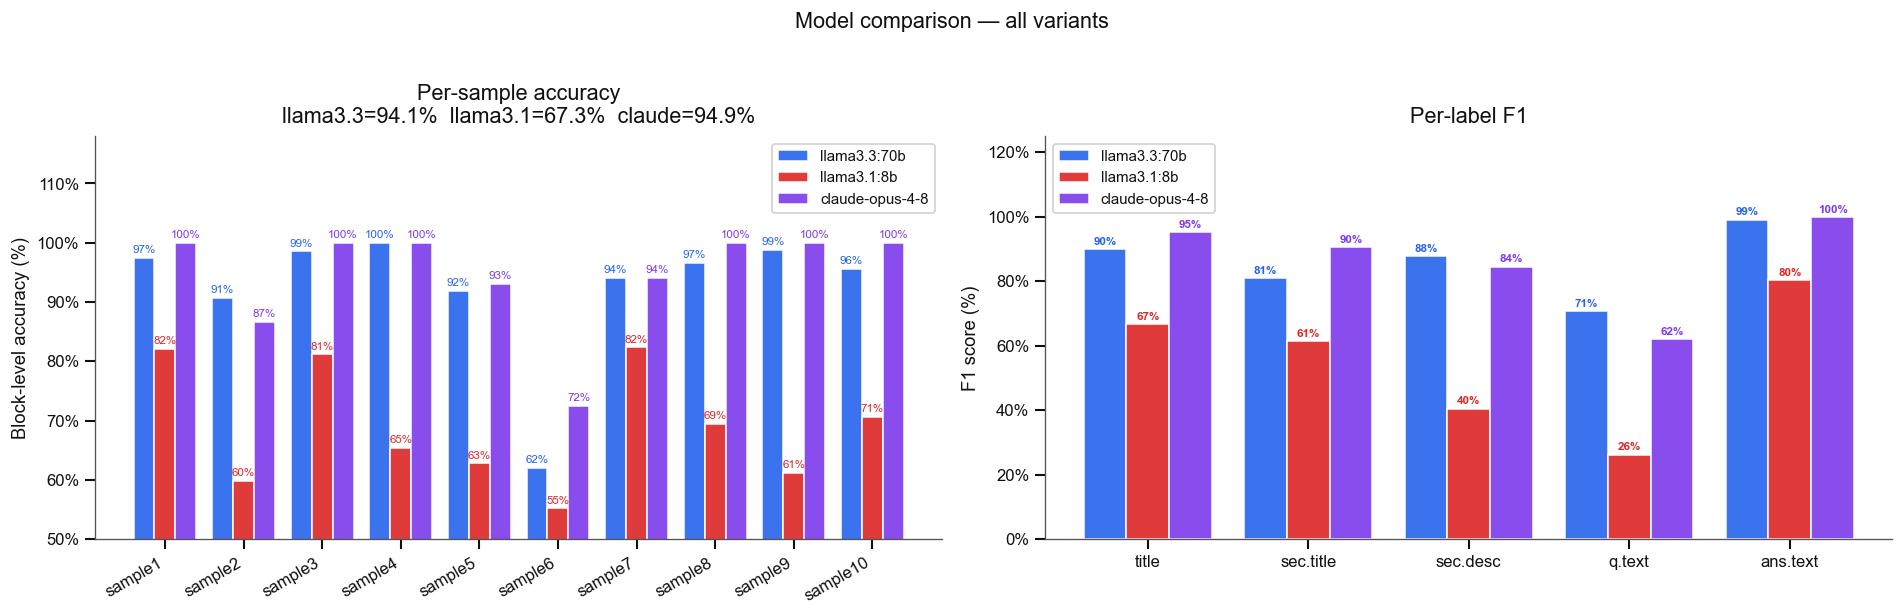

In [3]:
active = {m: variants[m] for m in TAGS if not variants[m][0].empty}
model_names = list(active.keys())
n_models = len(model_names)
w = 0.8 / n_models

x_labels = sorted(active[model_names[0]][0]["sample"].tolist(), key=_snum)
x = range(len(x_labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: per-sample accuracy ─────────────────────────────────────────────────
ax = axes[0]
for i, model in enumerate(model_names):
    df, _ = active[model]
    dfs = df.set_index("sample").loc[x_labels].reset_index()
    offset = (i - n_models/2 + 0.5) * w
    bars = ax.bar([xi + offset for xi in x], dfs["accuracy"]*100,
                  width=w, label=model, color=MODEL_COLORS[model], edgecolor="white", alpha=0.9)
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f"{bar.get_height():.0f}%", ha="center", va="bottom",
                    fontsize=7, color=MODEL_COLORS[model])

overall_str = "  ".join(
    f"{m.split(':')[0] if ':' in m else m.split('-')[0]}={active[m][0]['correct'].sum()/active[m][0]['total'].sum()*100:.1f}%"
    for m in model_names
)
ax.set_xticks(list(x)); ax.set_xticklabels(x_labels, rotation=30, ha="right")
ax.set_ylim(50, 118); ax.set_ylabel("Block-level accuracy (%)")
ax.set_title(f"Per-sample accuracy\n{overall_str}", pad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.legend(framealpha=0.9, fontsize=9); sns.despine(ax=ax)

# ── Right: per-label F1 ───────────────────────────────────────────────────────
ax = axes[1]
x2 = range(len(LABELS))
for i, model in enumerate(model_names):
    _, conf = active[model]
    f1_vals = [_f1(conf, l)*100 for l in LABELS]
    offset  = (i - n_models/2 + 0.5) * w
    bars = ax.bar([xi + offset for xi in x2], f1_vals,
                  width=w, label=model, color=MODEL_COLORS[model], edgecolor="white", alpha=0.9)
    for bar, v in zip(bars, f1_vals):
        if v > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                    f"{v:.0f}%", ha="center", va="bottom",
                    fontsize=7, fontweight="bold", color=MODEL_COLORS[model])
ax.set_xticks(list(x2)); ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylim(0, 125); ax.set_ylabel("F1 score (%)")
ax.set_title("Per-label F1", pad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.legend(framealpha=0.9, fontsize=9); sns.despine(ax=ax)

plt.suptitle("Model comparison — all variants", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

In [4]:
# F1 comparison table
print(f"{'Label':<22}" + "".join(f"  {m:>20}" for m in model_names))
print("-" * (22 + 22*n_models))
for lbl in LABELS:
    row = f"{lbl:<22}"
    for model in model_names:
        _, conf = active[model]
        row += f"  {_f1(conf,lbl)*100:>19.1f}%"
    print(row)
print("-" * (22 + 22*n_models))
row = f"{'OVERALL accuracy':<22}"
for model in model_names:
    df, _ = active[model]
    ov = df['correct'].sum()/df['total'].sum()*100
    row += f"  {ov:>19.1f}%"
print(row)

Label                           llama3.3:70b           llama3.1:8b       claude-opus-4-8
----------------------------------------------------------------------------------------
title                                  90.0%                 66.7%                 95.2%
section.title                          80.9%                 61.3%                 90.5%
section.description                    87.7%                 40.5%                 84.4%
question.text                          70.7%                 26.1%                 62.0%
answer.text                            99.0%                 80.2%                 99.9%
----------------------------------------------------------------------------------------
OVERALL accuracy                       94.1%                 67.3%                 94.9%


## 3 — Cross-Model Error Analysis

For each block, counts how many models labeled it correctly (0, 1, 2, or 3 out of 3).

| Category | Meaning |
|---|---|
| **all correct** | All models right |
| **2 correct** | Two models right, one wrong |
| **1 correct** | Only one model right |
| **all wrong** | All models wrong — genuinely hard blocks |

In [5]:
cross_rows = []
tag_list   = [(m, TAGS[m]) for m in model_names]

for mp in samples:
    stem    = mp.stem.replace("_dmp","")
    gold    = extract_gold(mp)
    # Load blocks for each model — skip sample if any model file is missing
    block_sets = {}
    for model, tag in tag_list:
        pp = LLM_DIR / f"{stem}_{tag}.json"
        if not pp.exists():
            break
        block_sets[model] = json.loads(pp.read_text(encoding="utf-8"))
    else:
        # All files present — compare block by block
        ref_blocks = block_sets[model_names[0]]
        for idx, ref_b in enumerate(ref_blocks):
            true_lbl = match(ref_b["text"], gold)
            if true_lbl is None:
                continue
            preds = {m: block_sets[m][idx].get("label","answer.text") for m in model_names}
            n_correct = sum(1 for p in preds.values() if p == true_lbl)
            row = {
                "sample":    stem,
                "text":      ref_b["text"][:120],
                "page":      ref_b.get("page","-"),
                "true":      true_lbl,
                "n_correct": n_correct,
            }
            row.update({f"pred_{m.replace(':','-').replace('.', '-')}": preds[m] for m in model_names})
            cross_rows.append(row)

df_cross = pd.DataFrame(cross_rows)
total    = len(df_cross)

print(f"Cross-model block analysis  (total matched blocks: {total})\n")
for n in [n_models, n_models-1, 1, 0]:
    label_str = {n_models: "all correct", 0: "all wrong"}.get(n, f"{n} correct")
    cnt = (df_cross["n_correct"]==n).sum()
    pct = cnt/total*100
    bar = "█" * int(pct/2)
    print(f"  {label_str:<14} {cnt:>4}  ({pct:>5.1f}%)  {bar}")

all_wrong_n = (df_cross["n_correct"]==0).sum()
print(f"\nConclusion: {all_wrong_n} blocks are hard for ALL models (all wrong).")

Cross-model block analysis  (total matched blocks: 726)

  all correct     482  ( 66.4%)  █████████████████████████████████
  2 correct       212  ( 29.2%)  ██████████████
  1 correct        29  (  4.0%)  █
  all wrong         3  (  0.4%)  

Conclusion: 3 blocks are hard for ALL models (all wrong).


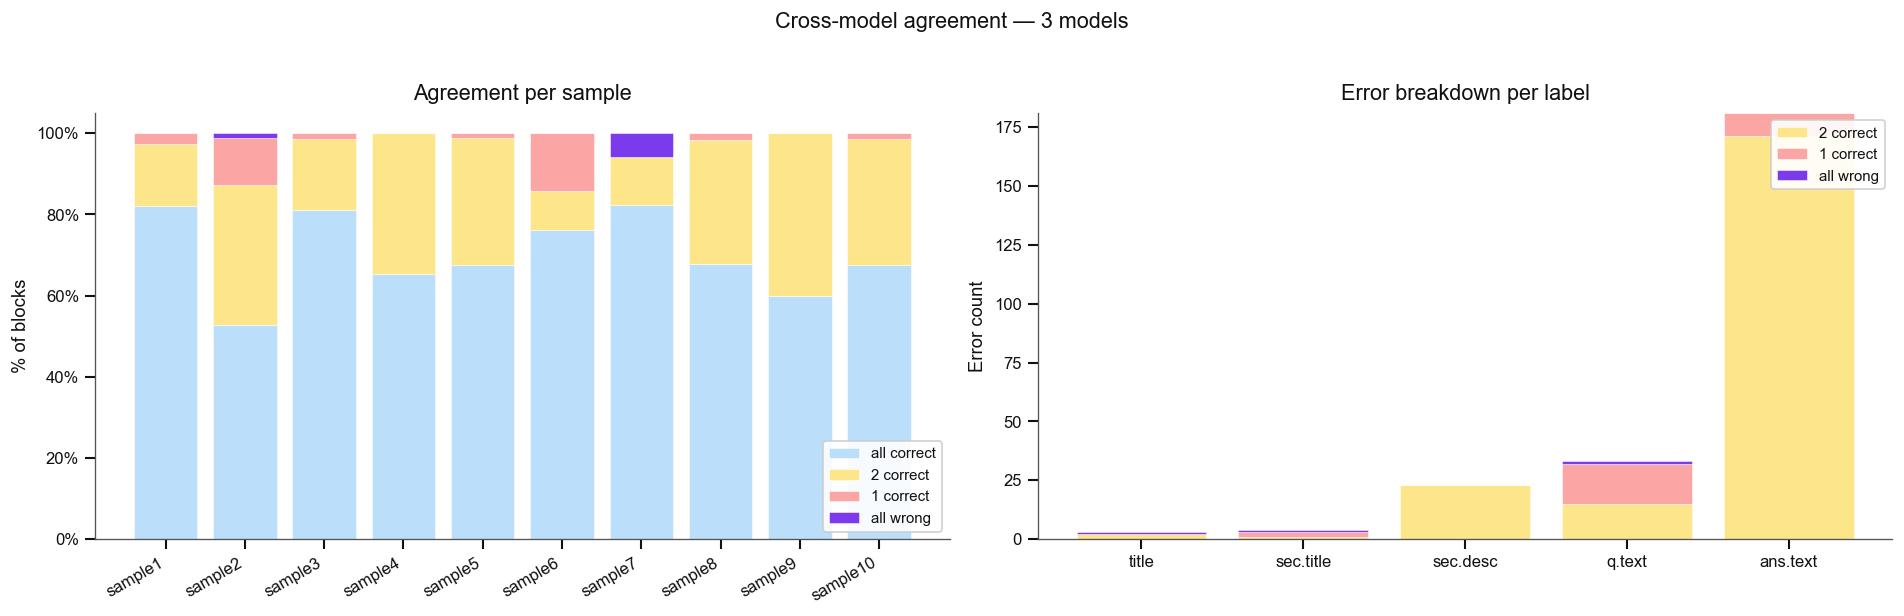

In [6]:
CAT_COLORS = {
    n_models:     "#bbdefb",   # all correct
    n_models - 1: "#fde68a",   # 2 correct (1 wrong)
    1:            "#fca5a5",   # 1 correct (2 wrong)
    0:            "#7c3aed",   # all wrong
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: stacked bar per sample ──────────────────────────────────────────────
ax = axes[0]
x_labels = sorted(df_cross["sample"].unique().tolist(), key=_snum)
bottoms  = {s: 0 for s in x_labels}
for n in [n_models, n_models-1, 1, 0]:
    label_str = {n_models: "all correct", 0: "all wrong"}.get(n, f"{n} correct")
    vals = []
    for s in x_labels:
        sub = df_cross[df_cross["sample"]==s]
        cnt = (sub["n_correct"]==n).sum()
        tot = len(sub)
        vals.append(cnt/tot*100 if tot else 0)
    ax.bar(x_labels, vals, bottom=[bottoms[s] for s in x_labels],
           label=label_str, color=CAT_COLORS[n], edgecolor="white", linewidth=0.3)
    for xi, (s, v) in enumerate(zip(x_labels, vals)):
        bottoms[s] += v

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=30, ha="right")
ax.set_ylim(0, 105); ax.set_ylabel("% of blocks")
ax.set_title("Agreement per sample", pad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.legend(loc="lower right", framealpha=0.9, fontsize=9)
sns.despine(ax=ax)

# ── Right: per-label breakdown ────────────────────────────────────────────────
ax = axes[1]
x2  = range(len(LABELS))
btm = [0]*len(LABELS)
for n in [n_models-1, 1, 0]:   # skip "all correct" — focus on errors
    label_str = {0: "all wrong"}.get(n, f"{n} correct")
    vals = [(df_cross[df_cross["true"]==l]["n_correct"]==n).sum() for l in LABELS]
    ax.bar(x2, vals, bottom=btm, label=label_str,
           color=CAT_COLORS[n], edgecolor="white", linewidth=0.3)
    btm = [b+v for b,v in zip(btm,vals)]
ax.set_xticks(list(x2)); ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylabel("Error count")
ax.set_title("Error breakdown per label", pad=8)
ax.legend(loc="upper right", framealpha=0.9, fontsize=9)
sns.despine(ax=ax)

plt.suptitle(f"Cross-model agreement — {n_models} models", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

In [7]:
# Blocks all models got wrong — the hardest cases
all_wrong_df = df_cross[df_cross["n_correct"]==0].copy()
if all_wrong_df.empty:
    print("No blocks that all models got wrong.")
else:
    pred_cols = [c for c in all_wrong_df.columns if c.startswith("pred_")]
    print(f"Blocks all {n_models} models got wrong ({len(all_wrong_df)} blocks)\n")
    pd.set_option("display.max_colwidth", 90)
    display(all_wrong_df[["sample","page","true"] + pred_cols + ["text"]]
            .sort_values(["true","sample"]).reset_index(drop=True))

Blocks all 3 models got wrong (3 blocks)



,sample,page,true,pred_llama3-3-70b,pred_llama3-1-8b,pred_claude-opus-4-8,text
0,sample2,2,question.text,section.description,section.description,section.description,"This should include, where appropriate:"
1,sample2,5,section.title,section.description,answer.text,section.description,data.
2,sample7,1,title,section.title,section.title,section.title,Resource/Data Sharing Plan


## 4 — Error Drill-Down

Edit the filter variables below to inspect any subset of errors.

In [8]:
# ── Edit these to filter ──────────────────────────────────────────────────────
FILTER_MODEL   = "claude-opus-4-8"  # any model name from TAGS, or "" for all
FILTER_TRUE    = "question.text"    # label or "" for all
FILTER_PRED    = ""                 # label or "" for all
FILTER_SAMPLE  = ""                 # e.g. "sample2" or "" for all
ONLY_ERRORS    = True               # True = show only misclassified blocks

# ── Apply filter ──────────────────────────────────────────────────────────────
# Find the pred column for the chosen model
if FILTER_MODEL:
    safe_model = FILTER_MODEL.replace(':','-').replace('.','-')
    pred_col   = f"pred_{safe_model}"
    if pred_col not in df_cross.columns:
        print(f"Model '{FILTER_MODEL}' not found. Available: {model_names}")
    mask = df_cross["n_correct"] < n_models if ONLY_ERRORS else pd.Series([True]*len(df_cross), index=df_cross.index)
    if FILTER_MODEL:
        mask &= df_cross[pred_col] != df_cross["true"] if ONLY_ERRORS else pd.Series([True]*len(df_cross), index=df_cross.index)
else:
    pred_col = None
    mask = df_cross["n_correct"] < n_models if ONLY_ERRORS else pd.Series([True]*len(df_cross), index=df_cross.index)

if FILTER_TRUE:   mask &= df_cross["true"]   == FILTER_TRUE
if FILTER_SAMPLE: mask &= df_cross["sample"] == FILTER_SAMPLE

pred_cols = [c for c in df_cross.columns if c.startswith("pred_")]
if FILTER_PRED and pred_col:
    mask &= df_cross[pred_col] == FILTER_PRED

subset = df_cross[mask].reset_index(drop=True)
print(f"Filter: model={FILTER_MODEL or 'all'}  true={FILTER_TRUE or 'any'}  "
      f"pred={FILTER_PRED or 'any'}  sample={FILTER_SAMPLE or 'all'}  only_errors={ONLY_ERRORS}")
print(f"Matching blocks: {len(subset)}\n")
if not subset.empty:
    pd.set_option("display.max_colwidth", 90)
    display(subset[["sample","page","true","n_correct"] + pred_cols + ["text"]])

Filter: model=claude-opus-4-8  true=question.text  pred=any  sample=all  only_errors=True
Matching blocks: 19



,sample,page,true,n_correct,pred_llama3-3-70b,pred_llama3-1-8b,pred_claude-opus-4-8,text
0,sample2,2,question.text,0,section.description,section.description,section.description,"This should include, where appropriate:"
1,sample2,2,question.text,2,question.text,question.text,section.description,the anticipated means for sharing and rationale for any restrictions on who may access...
2,sample2,2,question.text,2,question.text,question.text,section.description,and under what conditions;
3,sample2,2,question.text,1,question.text,answer.text,section.description,a timeline for sharing and preservation that addresses both the minimum length of time...
4,sample2,2,question.text,1,question.text,answer.text,section.description,will be available and any anticipated delay to data access after research findings are...
5,sample2,2,question.text,2,question.text,question.text,section.description,"any special requirements for data sharing, for example, proprietary software needed to..."
6,sample2,2,question.text,2,question.text,question.text,section.description,"or interpret data, applicable policies, provisions, and licenses for re-use and re-dis..."
7,sample2,2,question.text,2,question.text,question.text,section.description,"for the production of derivatives, including guidance for how data and data products s..."
8,sample2,2,question.text,2,question.text,question.text,section.description,cited;
9,sample2,2,question.text,1,question.text,answer.text,section.description,"any resources and capabilities (equipment, connections, systems, software, expertise, ..."
